<a href="https://colab.research.google.com/github/DiegoFelipini/DiegoFelipini/blob/main/PROJETO_PARTE_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://raw.githubusercontent.com/andre-marcos-perez/ebac-course-utils/main/media/logo/newebac_logo_black_half.png" alt="ebac-logo">

---

# **Módulo** | Projeto Pipeline_Telegram - Parte 1.
Caderno de **Exercícios**<br>
Professor [André Perez](https://www.linkedin.com/in/andremarcosperez/)

Aluno: Diego Felipini

---

# **Tópicos**

<ol type="1">

  <li>o que é istema transacional?;</li>
  <li>o que é ingestão?;</li>
  <li>o que é ETL?;</li>
   <li>o que é API?;</li>
   <li>Execução da 2° parte do trabalho;</li>
  <li>Apresentação;</li>
  <li>Storytelling;</li>
   <li>Conclusão;</li>
</ol>

---

##0. Estrura e codigos da primeira parte.

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
!pip install requests

In [4]:
!pip install boto3

In [10]:
#pacotes e bibliotecas

import warnings
warnings.filterwarnings('ignore')


import os
import json
import pandas as pd

import logging
from datetime import datetime, timedelta, timezone

import boto3
import requests

import pyarrow as pa
import pyarrow.parquet as pq

In [11]:
#autenticando o token

from getpass import getpass

token = getpass()

··········


In [12]:
# A url base é comum a todos os métodos da API

base_url = f'https://api.telegram.org/bot{token}'

In [13]:
response = requests.get(url=f'{base_url}/getMe')
print(f'{base_url}/getMe')

print(json.dumps(json.loads(response.text), indent=2))

https://api.telegram.org/bot7590735147:AAEB1DXkhNcTs3BeydKG-CSJ9h-ryzou12A/getMe
{
  "ok": true,
  "result": {
    "id": 7590735147,
    "is_bot": true,
    "first_name": "_md42_bot",
    "username": "md42_ebac_bot",
    "can_join_groups": false,
    "can_read_all_group_messages": false,
    "supports_inline_queries": false,
    "can_connect_to_business": false,
    "has_main_web_app": false
  }
}


In [17]:
response = requests.get(url=f'{base_url}/getUpdates')

print(json.dumps(json.loads(response.text), indent=2))

{
  "ok": true,
  "result": [
    {
      "update_id": 320669472,
      "message": {
        "message_id": 17,
        "from": {
          "id": 5385180079,
          "is_bot": false,
          "first_name": "DIEGO",
          "language_code": "pt-br"
        },
        "chat": {
          "id": -1002474898200,
          "title": "ebac-BOT-",
          "type": "supergroup"
        },
        "date": 1737028635,
        "text": "Bom dia Wagner."
      }
    },
    {
      "update_id": 320669473,
      "message": {
        "message_id": 18,
        "from": {
          "id": 1662059669,
          "is_bot": false,
          "first_name": "Wagner Viana"
        },
        "chat": {
          "id": -1002474898200,
          "title": "ebac-BOT-",
          "type": "supergroup"
        },
        "date": 1737028686,
        "text": "Bom dia tudo bem"
      }
    },
    {
      "update_id": 320669474,
      "message": {
        "message_id": 19,
        "from": {
          "id": 1662059669,
   

In [16]:
!python --version

Python 3.11.11


In [25]:
aws_api_gateway_url = getpass()

··········


In [26]:
response = requests.get(url=f'{base_url}/setWebhook?url={aws_api_gateway_url}')

print(json.dumps(json.loads(response.text), indent=2))


{
  "ok": true,
  "result": true,
  "description": "Webhook is already set"
}


In [27]:
response = requests.get(url=f'{base_url}/getWebhookInfo')

print(json.dumps(json.loads(response.text), indent=2))

{
  "ok": true,
  "result": {
    "url": "https://m9s3o9sjsl.execute-api.us-east-1.amazonaws.com/DEV",
    "has_custom_certificate": false,
    "pending_update_count": 11,
    "last_error_date": 1737039440,
    "last_error_message": "Wrong response from the webhook: 403 Forbidden",
    "max_connections": 40,
    "ip_address": "52.71.212.165"
  }
}


#1. O que é sistema transacional

Um `sistema transacional` é um conjunto integrado de componentes de hardware, software e bancos de dados, concebido para capturar, processar e armazenar dados gerados pelas operações diárias de uma organização. A principal função desses sistemas é garantir a integridade, consistência e durabilidade das transações, assegurando que as informações sejam registradas de forma precisa e confiável.

A coleta de dados ocorre em tempo real ou em lotes, dependendo da natureza da fonte e dos requisitos do negócio. Os dados capturados são então validados e transformados para um formato adequado para armazenamento. A etapa de armazenamento é crucial, sendo realizada em bancos de dados relacionais ou não relacionais `(Data Lakes)`, dependendo da complexidade e do volume dos dados a serem gerenciados.
>fonte: https://nordware.io/blog/sistema-transacional-entenda-o-significado-para-a-operacao-da-sua-empresa/

#2. O que é Ingestão

O objetivo da ingestão de dados deste projeto é coletar em tempo real todas as mensagens de texto trocadas na plataforma `Telegram`. Para o efeito será utilizada a `API` disponibilizada pela plataforma, que permitirá captar e armazenar esta informação de forma estruturada. Esta etapa é fundamental para garantir que o sistema tenha acesso a um conjunto de dados completo e atualizado, o que permitirá ao sistema realizar diversas análises e extrair insights relevantes.

#3. O que é ETL

A fase de extração, transformação e carregamento `(ETL)` é a fase encarregada de tratar os dados obtidos na fase transacional, ou seja, armazenados em camadas brutas dos sistemas analíticos. O dado bruto guardado passa por um procedimento contínuo onde é limpo, duplicado e armazenado utilizando técnicas de particionamento, orientadas a colunas e compressão. Ao concluir esse processo, os dados ficam preparados para análise pelos especialistas da área.

#4. O que é API


A arquitetura `REST`, que significa Transferência de Estado Representacional, é a mais comum na criação de APIs, já que proporciona uma metodologia clara e adaptável para desenvolver serviços online. Dentro dessa arquitetura, as ações realizadas nos recursos são determinadas por meio de verbos `HTTP`, como `GET`, `POST`, `PUT` e `DELETE`, enquanto as informações são apresentadas em formatos como `JSON` ou `XML`.


A proteção das APIs é crucial para salvaguardar as informações e assegurar a solidez do sistema. Ferramentas como autenticação `(básica, token, OAuth)` e autorização `(permissões)` são empregadas para regular o acesso aos recursos disponíveis. Ademais, o uso de chaves de API e a adoção de práticas seguras, como a criptografia e a checagem de dados, são vitais para evitar ataques e proteger a privacidade das informações.


A criação de uma API passa por várias fases, começando com o planejamento e o design da estrutura, seguindo pela execução, testes e elaboração da documentação. É fundamental que a API esteja adequadamente documentada para que outros desenvolvedores possam utilizá-la com facilidade.
>fonte: https://aws.amazon.com/pt/what-is/api/

#5. Execução da 2° parte do trabalho

###5.1. Criação do bucket raw



Crie um `bucket` no `AWS S3` para o armazenamento de dados crus, não se esqueça de adicionar o sufixo `-raw`.

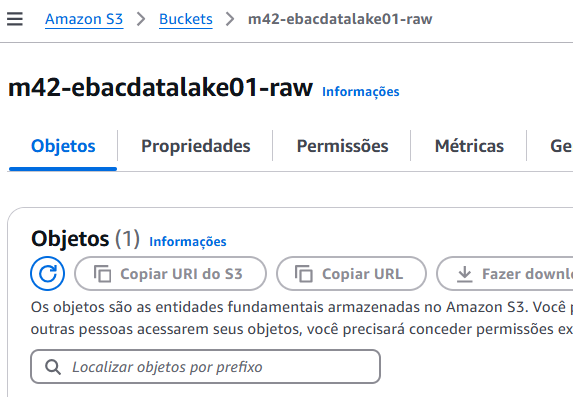

###5.2 Criação da função lambda para dados crus.



Crie uma função no `AWS Lambda` para recebimento das mensagens e armazenamento no formato JSON no `bucket` de dados crus. Não se esqueça de configurar as variáveis de ambiente e de adicionar as permissão de interação com `AWS S3` no `AWS IAM`.



```python
import os
import json
import logging
from datetime import datetime, timezone

import boto3


def lambda_handler(event: dict, context: dict) -> dict:

  '''
  Recebe uma mensagens do Telegram via AWS API Gateway, verifica no
  seu conteúdo se foi produzida em um determinado grupo e a escreve,
  em seu formato original JSON, em um bucket do AWS S3.
  '''

  # vars de ambiente

  BUCKET = os.environ['AWS_S3_BUCKET']
  TELEGRAM_CHAT_ID = int(os.environ['TELEGRAM_CHAT_ID'])

  # vars lógicas

  tzinfo = timezone(offset=timedelta(hours=-3))
  date = datetime.now(tzinfo).strftime('%Y-%m-%d')
  timestamp = datetime.now(tzinfo).strftime('%Y%m%d%H%M%S%f')

  filename = f'{timestamp}.json'

  # código principal

  client = boto3.client('s3')

  try:

    # message = json.loads(event["body"])
    message = event
    chat_id = message["message"]["chat"]["id"]

    if chat_id == TELEGRAM_CHAT_ID:

      with open(f"/tmp/{filename}", mode='w', encoding='utf8') as fp:
        json.dump(message, fp)

      client.upload_file(f'/tmp/{filename}', BUCKET, f'telegram/context_date={date}/{filename}')

  except Exception as exc:
      logging.error(msg=exc)
      return dict(statusCode="500")

  else:
      return dict(statusCode="200")
```



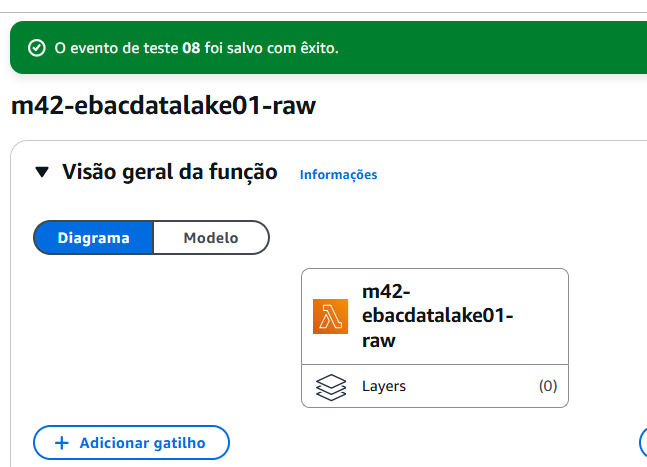

###5.3. AWS API Gateway




O `Amazon API Gateway` serve como o ponto de acesso central para aplicações que utilizam dados, lógica de negócios ou recursos de serviços back-end na AWS. Neste projeto, ele terá uma função essencial ao receber os dados oriundos das plataformas de mensagens.

>API CRIADO E TESTADO COM SUCESSO.

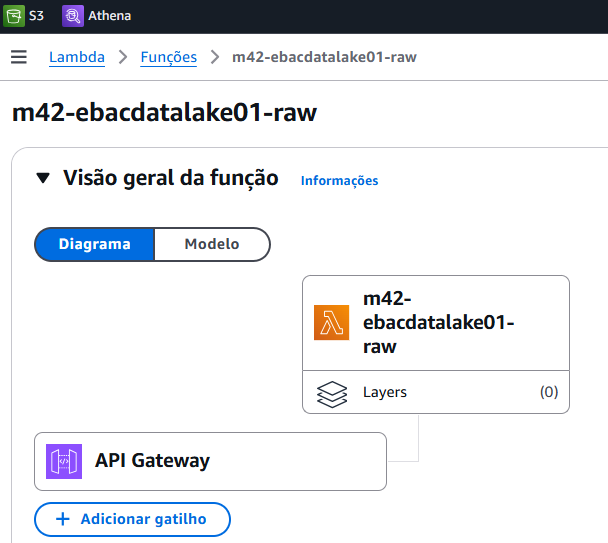

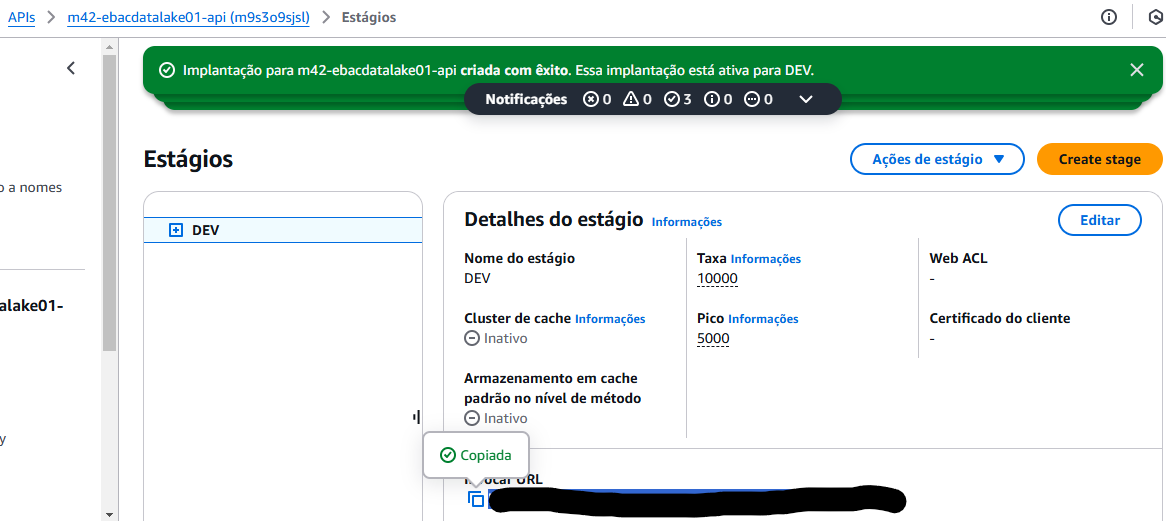

`Nota:` Para testar a função com evento do próprio AWS Lambda, substitua o código `message = json.loads(event["body"])` por `message = event`. Lembre-se que o primeiro só faz sentido na integração com o AWS API Gateway.

###5.4. Criação do bucket enriched

Crie um `bucket` no `AWS S3` para o armazenamento de dados enriquecidos, não se esqueça de adicionar o sufixo `-enriched`.

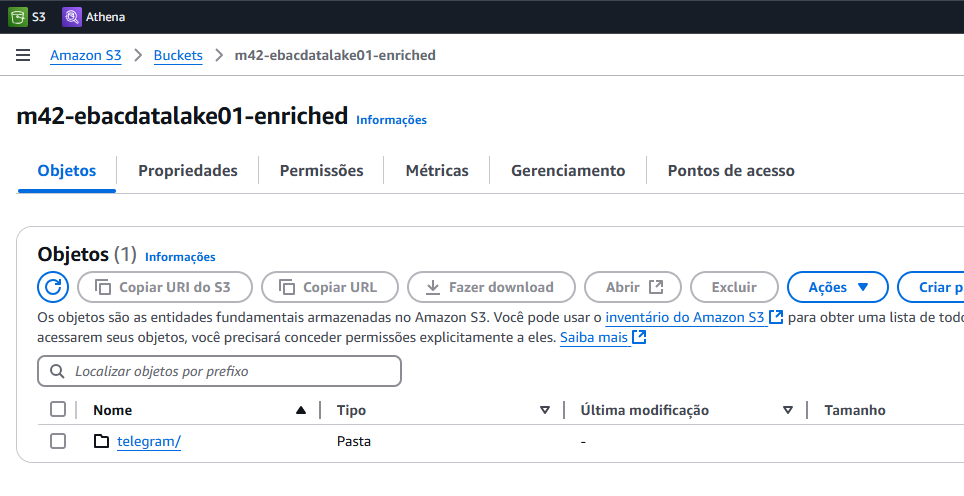

###5.5. Criação função lambada para salvar em um aquivo parquet



Cria uma função no `AWS Lambda` para processar as mensagens JSON de uma única partição do dia anterior (D-1), armazenadas no *bucket* de dados crus. Salve o resultado em um único arquivo PARQUET, também particionado por dia. Não se esqueça de configurar as variáveis de ambiente, de adicionar as permissão de interação com `AWS S3` no `AWS IAM`, de configurar o *timeout* e de adicionar a *layer* com o código do pacote Python PyArrow.

> **Nota**: Para testar a função, substitua o código `date = (datetime.now(tzinfo) - timedelta(days=1)).strftime('%Y-%m-%d')` por `date = (datetime.now(tzinfo) - timedelta(days=0)).strftime('%Y-%m-%d')`, permitindo assim o processamento de mensagens de um mesmo dia.



```python
import os
import json
import logging
from datetime import datetime, timedelta, timezone

import boto3
import pyarrow as pa
import pyarrow.parquet as pq


def lambda_handler(event: dict, context: dict) -> bool:

  '''
  Diariamente é executado para compactar as diversas mensagensm, no formato
  JSON, do dia anterior, armazenadas no bucket de dados cru, em um único
  arquivo no formato PARQUET, armazenando-o no bucket de dados enriquecidos
  '''

  # vars de ambiente

  RAW_BUCKET = os.environ['AWS_S3_BUCKET']
  ENRICHED_BUCKET = os.environ['AWS_S3_ENRICHED']

  # vars lógicas

  tzinfo = timezone(offset=timedelta(hours=-3))
  date = (datetime.now(tzinfo) - timedelta(days=1)).strftime('%Y-%m-%d')
  timestamp = datetime.now(tzinfo).strftime('%Y%m%d%H%M%S%f')

  # código principal

  table = None
  client = boto3.client('s3')

  try:

      response = client.list_objects_v2(Bucket=RAW_BUCKET, Prefix=f'telegram/context_date={date}')

      for content in response['Contents']:

        key = content['Key']
        client.download_file(RAW_BUCKET, key, f"/tmp/{key.split('/')[-1]}")

        with open(f"/tmp/{key.split('/')[-1]}", mode='r', encoding='utf8') as fp:

          data = json.load(fp)
          data = data["message"]

        parsed_data = parse_data(data=data)
        iter_table = pa.Table.from_pydict(mapping=parsed_data)

        if table:

          table = pa.concat_tables([table, iter_table])

        else:

          table = iter_table
          iter_table = None
          
      pq.write_table(table=table, where=f'/tmp/{timestamp}.parquet')
      client.upload_file(f"/tmp/{timestamp}.parquet", ENRICHED_BUCKET, f"telegram/context_date={date}/{timestamp}.parquet")

      return True
  
  except Exception as exc:
      logging.error(msg=exc)
      return False
      
      
def parse_data(data: dict) -> dict:

  date = datetime.now().strftime('%Y-%m-%d')
  timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

  parsed_data = dict()

  for key, value in data.items():

      if key == 'from':
          for k, v in data[key].items():
              if k in ['id', 'is_bot', 'first_name']:
                parsed_data[f"{key if key == 'chat' else 'user'}_{k}"] = [v]

      elif key == 'chat':
          for k, v in data[key].items():
              if k in ['id', 'type']:
                parsed_data[f"{key if key == 'chat' else 'user'}_{k}"] = [v]

      elif key in ['message_id', 'date', 'text']:
          parsed_data[key] = [value]

  if not 'text' in parsed_data.keys():
    parsed_data['text'] = [""]

  return parsed_data
```



* Telegram Schema

| Column Name      | Data Type |
|------------------|-----------|
| message_id       | int64     |
| user_id          | int64     |
| user_is_bot      | bool      |
| user_first_name  | object    |
| chat_id          | int64     |
| chat_type        | object    |
| date             | int64     |
| text             | object    |

>Função lambda configurada ja com layer

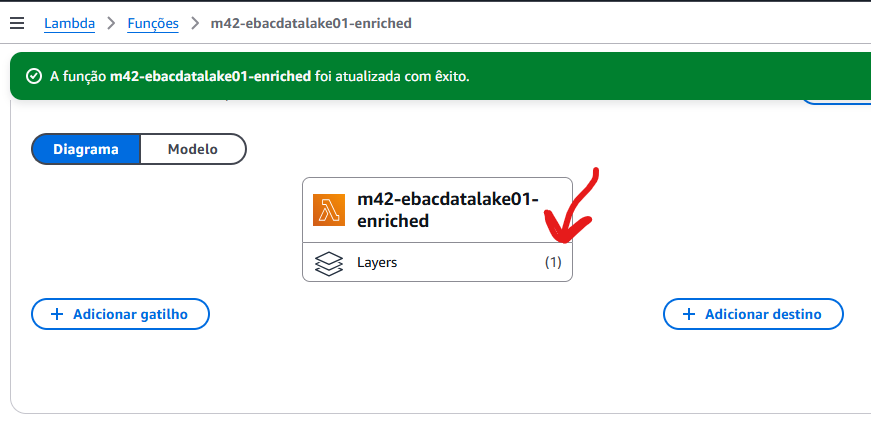

>Teste realizado em função lambada retornou thue

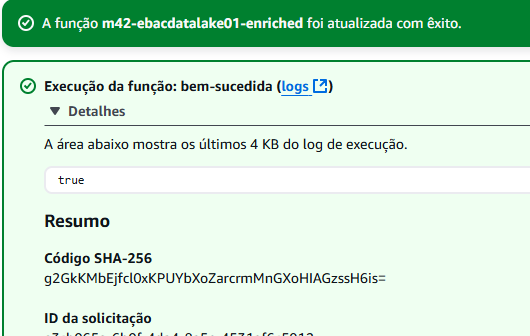

5.6. Crie uma regra no `AWS Event Bridge` para executar a função do `AWS Lambda` todo dia a meia noite no horário de Brasília (GMT-3).

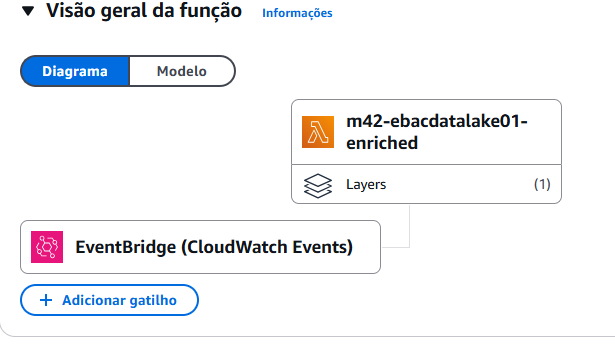

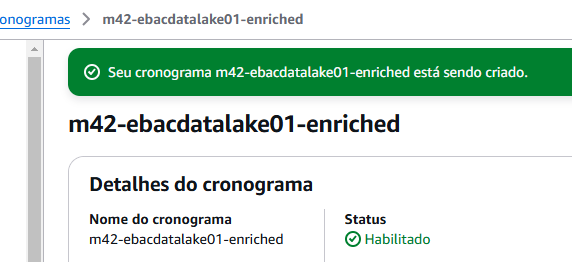

## 6\. Apresentação

6.1. Cria a tabela no `AWS Athena` que aponte para os dados armazenados no bucket enriquecido do `AWS S3`.




```sql
CREATE EXTERNAL TABLE `telegram`(
  `message_id` bigint,
  `user_id` bigint,
  `user_is_bot` boolean,
  `user_first_name` string,
  `chat_id` bigint,
  `chat_type` string,
  `text` string,
  `date` bigint)
PARTITIONED BY (
  `context_date` date)
ROW FORMAT SERDE
  'org.apache.hadoop.hive.ql.io.parquet.serde.ParquetHiveSerDe'
STORED AS INPUTFORMAT
  'org.apache.hadoop.hive.ql.io.parquet.MapredParquetInputFormat'
OUTPUTFORMAT
  'org.apache.hadoop.hive.ql.io.parquet.MapredParquetOutputFormat'
LOCATION
  's3://m42-ebacdatalake01-enriched/telegram/'
```




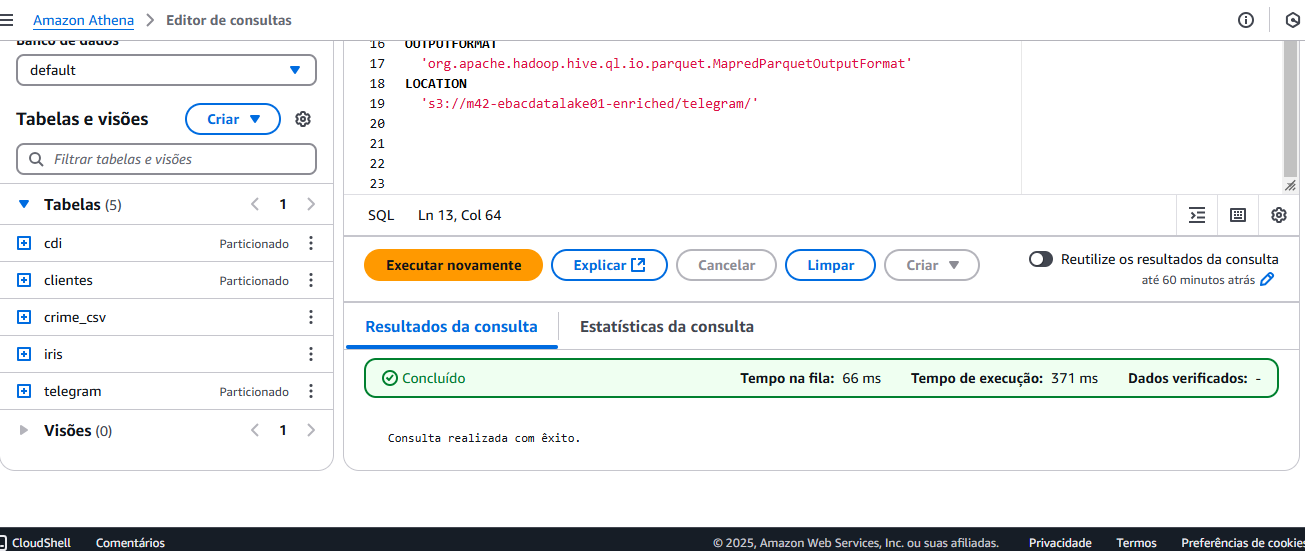

6.2. Execute o comando `MSCK REPAIR TABLE <nome-tabela>` para carregar as partições.




```sql
MSCK REPAIR TABLE telegram;
```



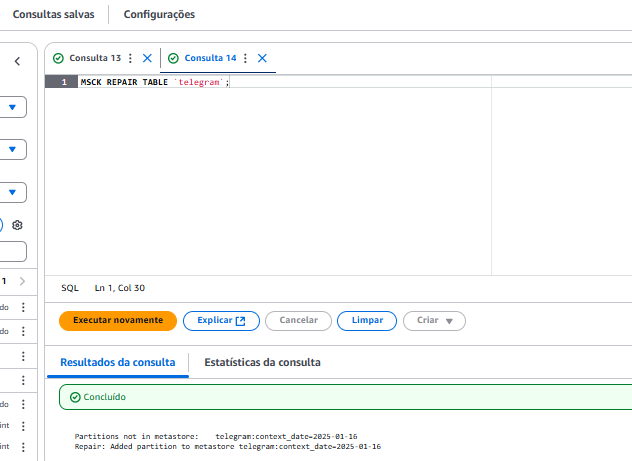

6.3. Execute as consultas SQL para explorar os dados.



```sql
SELECT * FROM telegram;
```



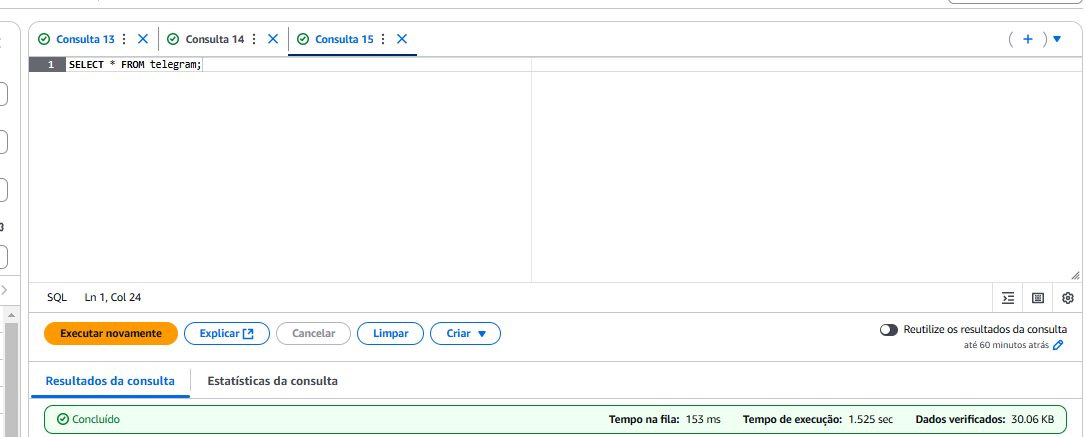

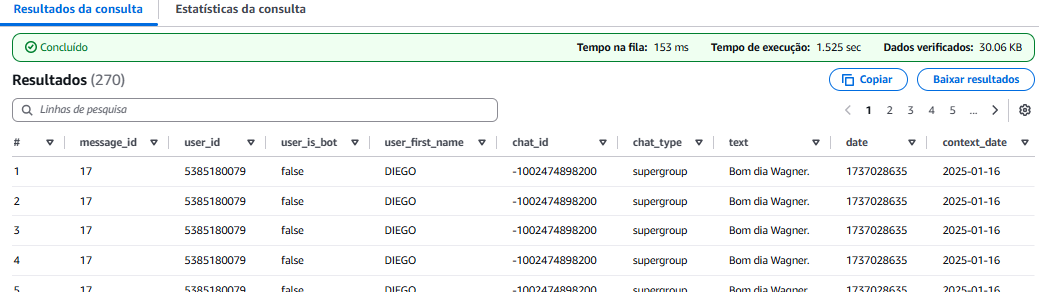

7. Storytelling

Análise Exploratória de Dados com SQL

>Quantidade de mensagens por dia.



```sql
SELECT
  context_date,
  count(1) AS "message_amount"
FROM "telegram"
GROUP BY context_date
ORDER BY context_date DESC
```



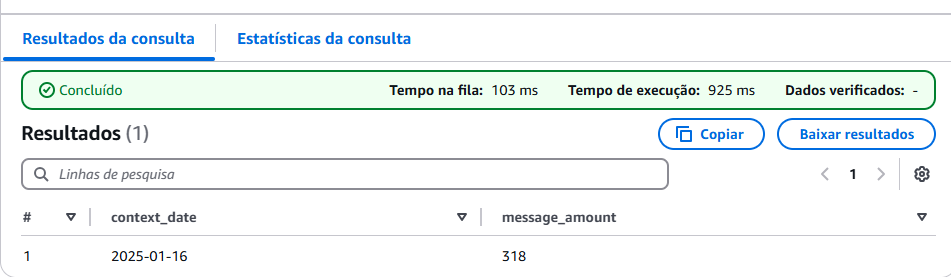

>Quantidade de mensagens por usuário por dia.



```sql
SELECT
  user_id,
  user_first_name,
  context_date,
  count(1) AS "message_amount"
FROM "telegram"
GROUP BY
  user_id,
  user_first_name,
  context_date
ORDER BY context_date DESC
```



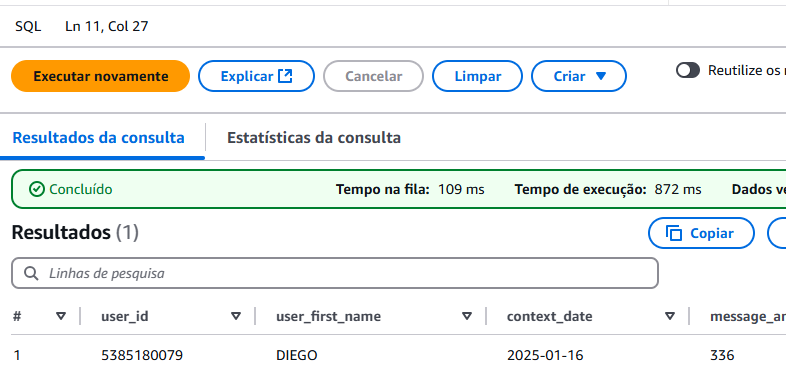

>Média do tamanho das mensagens por usuário por dia



```sql
SELECT
  user_id,
  user_first_name,
  context_date,
  CAST(AVG(length(text)) AS INT) AS "avg_message_length"
FROM "telegram"
GROUP BY
  user_id,
  user_first_name,
  context_date
ORDER BY context_date DESC
```



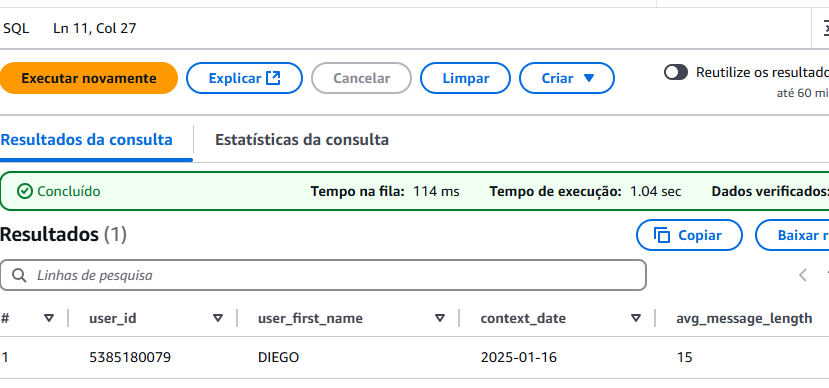

>Quantidade de mensagens por hora por dia da semana por número da semana.



```sql
WITH
parsed_date_cte AS (
    SELECT
        *,
        CAST(date_format(from_unixtime("date"),'%Y-%m-%d %H:%i:%s') AS timestamp) AS parsed_date
    FROM "telegram"
),
hour_week_cte AS (
    SELECT
        *,
        EXTRACT(hour FROM parsed_date) AS parsed_date_hour,
        EXTRACT(dow FROM parsed_date) AS parsed_date_weekday,
        EXTRACT(week FROM parsed_date) AS parsed_date_weeknum
    FROM parsed_date_cte
)
SELECT
    parsed_date_hour,
    parsed_date_weekday,
    parsed_date_weeknum,
    count(1) AS "message_amount"
FROM hour_week_cte
GROUP BY
    parsed_date_hour,
    parsed_date_weekday,
    parsed_date_weeknum
ORDER BY
    parsed_date_weeknum,
    parsed_date_weekday
```



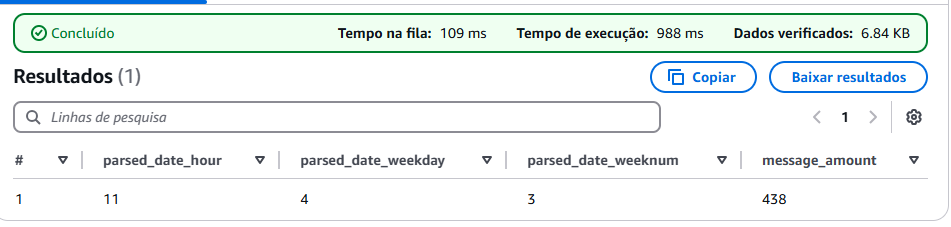

>Quantas mensagens tiveram erros de digitação?

```sql
SELECT count(*) AS messages_with_typos
FROM telegram
WHERE text LIKE '%*%'
```

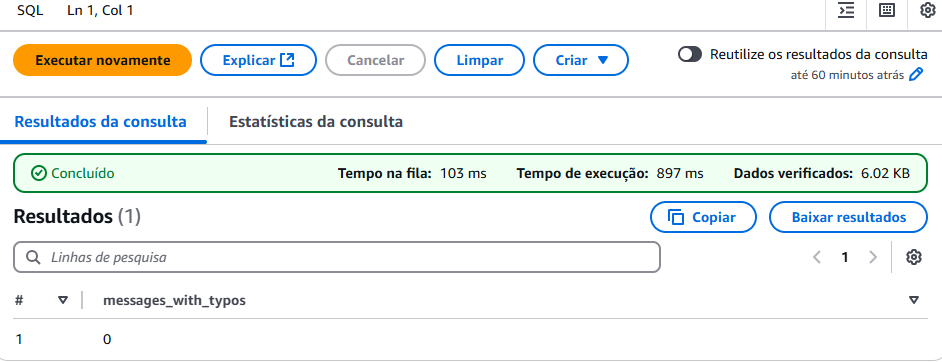

<a id='conclu'></a>
## 8. Conclusão

A plataforma do Telegram, aliada à análise de dados e ao uso de serviços em nuvem como a AWS, desempenha um papel fundamental no aprimoramento das atividades comerciais. O Telegram, com sua interface eficiente e acessível a qualquer momento, facilita a comunicação com os clientes. A integração com a AWS eleva essa comunicação, uma vez que assegura escalabilidade, flexibilidade e confiabilidade, permitindo ajustes dinâmicos nos recursos conforme as necessidades surgem.

A análise de dados, desenvolvida por meio de pipelines na nuvem, ganha em eficiência com esta estratégia, possibilitando um processamento abrangente e um armazenamento seguro. Isso permite a exploração de insights valiosos a partir dos vastos volumes de dados gerados nas interações dos usuários com o Telegram.

Entre as vantagens, destaca-se também a diminuição de custos associados à nuvem, eliminando a necessidade de investimentos em infraestrutura física e promovendo agilidade na adaptação às mudanças nas demandas operacionais, sempre mantendo uma operação eficiente. A segurança é um aspecto crucial, especialmente ao lidar com informações sensíveis dos clientes nas interações na plataforma. As soluções em nuvem como a AWS implementam medidas rigorosas para proteger dados críticos contra ataques cibernéticos.

Em resumo, essa sinergia oferece uma metodologia colaborativa que enriquece a experiência do cliente no Telegram, otimiza a operação e proporciona suporte estratégico para tomadas de decisão. Estabelecer um pipeline de análise de dados é vital no contexto empresarial, fornecendo os recursos indispensáveis para fomentar a inovação e a excelência.

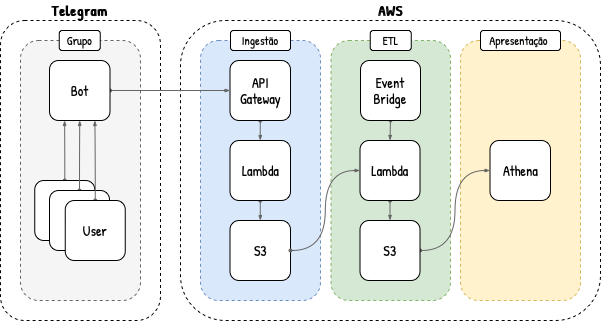

#Ferramentas utilizadas


*   Python
*   Aws
*   SQL
*   Telegram Bots
